# 02 · Unit economics: who earns what on a card purchase

Feature 3 prices every purchase of the synthetic network and splits the merchant discount
rate (MDR) among the three parties that receive it, then subtracts each one's operating
costs:

- the **issuer** keeps the interchange net of its network fees, and pays for rewards,
  grace-period funding, expected credit losses, fraud and processing;
- the **network** collects assessment, authorization and cross-border fees from both sides,
  which are its revenue;
- the **acquirer** keeps what is left of the MDR and pays for processing.

Merchants pay a **blended** flat rate by MCC group, or **IC++** (interchange and network fees
at cost, plus the acquirer's markup) when they are large or medium merchants of a bank
acquirer.

> **Synthetic data.** Every figure follows from `config/*.yaml` and `docs/assumptions.md`:
> the deliverable is the framework, not the numbers. Run `python -m ips.tasks generate`
> first.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, PercentFormatter

from ips.data_gen.interchange_table import build_interchange_table
from ips.economics.metrics import issuer_contribution, net_revenue_yield, relative_burden
from ips.economics.pnl import MerchantCost, compute_pnl, pnl_by
from ips.economics.revenue_bridge import revenue_bridge
from ips.utils.config import SIZE_TIERS, load_config, resolve_path

pl.Config.set_thousands_separator(",")
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(160)
pl.Config.set_tbl_cols(12)
pl.Config.set_fmt_str_lengths(60)
start = time.perf_counter()
cfg = load_config()
raw = resolve_path(cfg.output.raw_dir)

Chart style: the dataviz reference palette on a light surface, as in notebook 01.
Categorical colours in a fixed order (validated for colour-vision deficiency), blue and red
as the two poles of a change, neutral gray for what has no identity (operating costs, year
totals). Every chart is followed by its table.

In [2]:
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical slots 1-4, fixed order
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
UP, DOWN = "#2a78d6", "#e34948"  # diverging poles: increase and decrease
COSTS = AXIS  # operating costs: neutral, no identity
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.axisbelow": True,
        "axes.titlelocation": "left",
        "axes.titlepad": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "xtick.color": AXIS,
        "ytick.color": AXIS,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "legend.frameon": False,
        "legend.labelcolor": INK_2,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
    }
)


def compact(value, _pos=None):
    """Three significant digits: 1,234 -> 1.23k; 5,600,000 -> 5.60M."""
    for threshold, suffix in ((1e12, "T"), (1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(value) >= threshold:
            return f"{value / threshold:#.3g}".rstrip(".") + suffix
    return f"{value:,.0f}"


def pretty(name):
    return str(name).replace("_", " ").capitalize()


def text_on(fill):
    """White or ink text, whichever contrasts more with the fill."""
    channels = [int(fill[i : i + 2], 16) / 255 for i in (1, 3, 5)]
    linear = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in channels]
    lum = 0.2126 * linear[0] + 0.7152 * linear[1] + 0.0722 * linear[2]
    return "#ffffff" if 1.05 / (lum + 0.05) >= (lum + 0.05) / 0.054 else INK


PRODUCTS = list(cfg.products)
PRODUCT_ORDER = {product: i for i, product in enumerate(PRODUCTS)}

In [3]:
tx = pl.read_parquet(raw / "transactions.parquet")
merchants = pl.read_parquet(raw / "merchants.parquet")
acquirers = pl.read_parquet(raw / "acquirers.parquet")
pnl = compute_pnl(tx, build_interchange_table(cfg), cfg, merchants=merchants)
totals = pnl.totals()
gdv, mdr = totals["gdv_cop"], totals["mdr_cop"]
# Conservación: emisor, red y adquirente reciben exactamente el MDR que pagan los comercios.
received = totals["issuer_gross_cop"] + totals["network_revenue_cop"] + totals["acquirer_gross_cop"]
assert abs(received - mdr) <= 1e-9 * mdr, received - mdr
print(
    f"{tx.height:,} purchases | GDV {compact(gdv)} COP | MDR {mdr / gdv:.2%} of GDV | "
    f"network yield {totals['net_revenue_yield_bps']:.1f} bps | "
    f"conservation gap {received - mdr:.1e} COP"
)

6,000,000 purchases | GDV 1.01T COP | MDR 2.10% of GDV | network yield 28.1 bps | conservation gap 0.0e+00 COP


## 1. Where 100 COP of MDR goes

The top bar is the conservation identity: issuer, network and acquirer receive exactly the
MDR the merchants pay (checked above). The bottom bar subtracts each party's operating costs
inside its own slice: the gray part of the issuer's slice is what rewards, funding, expected
losses, fraud and processing take. The network's own operating costs are outside the model.

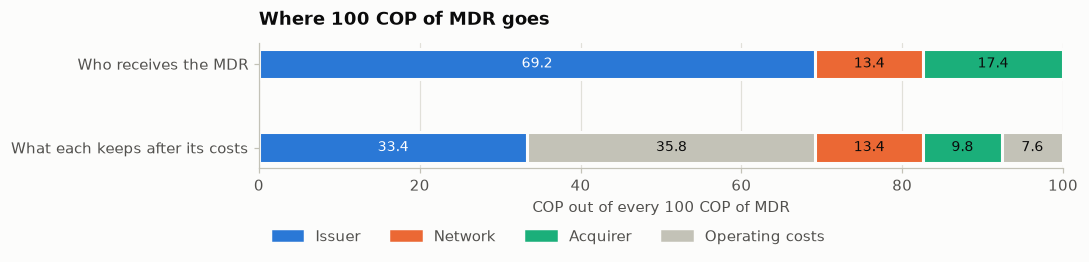

In [4]:
ISSUER_COSTS = (
    "rewards_cop",
    "funding_cop",
    "credit_loss_cop",
    "issuer_processing_cop",
    "fraud_loss_cop",
)
per_100 = 100 / mdr
bars = {
    "Who receives the MDR": [
        (totals["issuer_gross_cop"], SERIES[0]),
        (totals["network_revenue_cop"], SERIES[1]),
        (totals["acquirer_gross_cop"], SERIES[2]),
    ],
    "What each keeps after its costs": [
        (totals["issuer_contribution_cop"], SERIES[0]),
        (sum(totals[c] for c in ISSUER_COSTS), COSTS),
        (totals["network_revenue_cop"], SERIES[1]),
        (totals["acquirer_contribution_cop"], SERIES[2]),
        (totals["acquirer_processing_cop"], COSTS),
    ],
}
fig, ax = plt.subplots(figsize=(10, 2.9))
for y, segments in enumerate(bars.values()):
    left = 0.0
    for value, color in segments:
        width = value * per_100
        ax.barh(y, width, left=left, height=0.36, color=color, edgecolor=SURFACE, linewidth=2)
        if width >= 5:
            ax.text(
                left + width / 2,
                y,
                f"{width:.1f}",
                ha="center",
                va="center",
                fontsize=9,
                color=text_on(color),
            )
        left += width
ax.set_yticks(range(len(bars)), list(bars))
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("COP out of every 100 COP of MDR")
ax.grid(axis="y", visible=False)
ax.set_title("Where 100 COP of MDR goes")
legend = [
    ("Issuer", SERIES[0]),
    ("Network", SERIES[1]),
    ("Acquirer", SERIES[2]),
    ("Operating costs", COSTS),
]
ax.legend(
    handles=[Patch(color=c, label=n) for n, c in legend],
    ncol=4,
    loc="upper left",
    bbox_to_anchor=(0, -0.38),
)
fig.tight_layout()
plt.show()

In [5]:
STATEMENT = [
    ("Merchant", "MDR paid", "mdr_cop", 1),
    ("Issuer", "Interchange received", "interchange_cop", 1),
    ("Issuer", "Network fees, issuer side", "issuer_network_fee_cop", -1),
    ("Issuer", "= Gross", "issuer_gross_cop", 1),
    ("Issuer", "Rewards", "rewards_cop", -1),
    ("Issuer", "Grace-period funding", "funding_cop", -1),
    ("Issuer", "Expected credit loss", "credit_loss_cop", -1),
    ("Issuer", "Processing", "issuer_processing_cop", -1),
    ("Issuer", "Fraud not charged back", "fraud_loss_cop", -1),
    ("Issuer", "= Contribution", "issuer_contribution_cop", 1),
    ("Network", "Assessment", "network_assessment_cop", 1),
    ("Network", "Authorization", "network_authorization_cop", 1),
    ("Network", "Cross-border", "network_cross_border_cop", 1),
    ("Network", "= Revenue", "network_revenue_cop", 1),
    ("Acquirer", "= Gross (MDR - interchange - its network fees)", "acquirer_gross_cop", 1),
    ("Acquirer", "Processing", "acquirer_processing_cop", -1),
    ("Acquirer", "= Contribution", "acquirer_contribution_cop", 1),
    ("Merchant", "Chargebacks, on top of the MDR", "chargeback_cop", 1),
]
pl.DataFrame(
    [
        {
            "party": party,
            "line": line,
            "COP per 100 COP of MDR": sign * totals[column] * per_100,
            "bps of GDV": sign * totals[column] / gdv * 1e4,
        }
        for party, line, column, sign in STATEMENT
    ]
).with_columns(cs.float().round(2))

party,line,COP per 100 COP of MDR,bps of GDV
str,str,f64,f64
"""Merchant""","""MDR paid""",100.0,209.58
"""Issuer""","""Interchange received""",73.11,153.22
"""Issuer""","""Network fees, issuer side""",-3.9,-8.18
"""Issuer""","""= Gross""",69.2,145.04
"""Issuer""","""Rewards""",-18.33,-38.42
"""Issuer""","""Grace-period funding""",-5.55,-11.64
"""Issuer""","""Expected credit loss""",-4.49,-9.42
"""Issuer""","""Processing""",-6.62,-13.88
"""Issuer""","""Fraud not charged back""",-0.81,-1.69


Out of every 100 COP of MDR the issuer receives more than two thirds, the acquirer
about a sixth and the network the rest. Costs change the picture: rewards alone take more than a
quarter of the issuer's slice, and after all its costs the issuer keeps less than half of it.

Bank acquirers charge IC++ to their large and medium merchants and keep only the
negotiated markup there, so their gross margin sits below the aggregators', which price
everything at the blended list rate. The foreign acquirer appears only through purchases
with Colombian cards, the international slice of its business: even with the surcharge on
foreign cards that slice is thin, and its home-market business is outside the model.

In [6]:
ACQUIRER_ORDER = {a: i for i, a in enumerate(acquirers["acquirer_id"].cast(pl.Utf8))}
icpp_share = pnl.transactions.group_by(pl.col("acquirer_id").cast(pl.Utf8)).agg(
    (
        pl.col("amount_cop").filter(pl.col("pricing_model") == "icpp").sum()
        / pl.col("amount_cop").sum()
    ).alias("IC++ share of volume")
)
(
    pnl_by(pnl, [pl.col("acquirer_id").cast(pl.Utf8)])
    .join(acquirers.select(pl.col("acquirer_id").cast(pl.Utf8), "acquirer_type"), on="acquirer_id")
    .join(icpp_share, on="acquirer_id")
    .sort(pl.col("acquirer_id").replace_strict(ACQUIRER_ORDER))
    .select(
        "acquirer_id",
        "acquirer_type",
        (pl.col("gdv_cop") / gdv).alias("share of GDV"),
        "IC++ share of volume",
        pl.col("effective_mdr_rate").alias("effective MDR"),
        pl.col("acquirer_margin_rate").alias("gross margin"),
        (pl.col("acquirer_contribution_cop") / pl.col("gdv_cop")).alias("contribution margin"),
    )
    .with_columns(cs.float().round(4))
)

acquirer_id,acquirer_type,share of GDV,IC++ share of volume,effective MDR,gross margin,contribution margin
str,str,f64,f64,f64,f64,f64
"""ACQ_BANK_A""","""bank""",0.2251,0.6292,0.019,0.0033,0.0017
"""ACQ_BANK_B""","""bank""",0.1711,0.6475,0.0191,0.0033,0.0016
"""ACQ_BANK_C""","""bank""",0.1325,0.6844,0.0207,0.0031,0.0016
"""ACQ_AGG_X""","""aggregator""",0.1878,0.0,0.0204,0.0044,0.0028
"""ACQ_AGG_Y""","""aggregator""",0.1566,0.0,0.0208,0.0045,0.0029
"""ACQ_AGG_Z""","""aggregator""",0.0796,0.0,0.0207,0.0044,0.0028
"""ACQ_FOREIGN""","""foreign""",0.0474,0.0,0.0405,0.001,-0.0003


## 2. Issuers: the interchange pays for the card

Each pair of dots is one product: on the right, the interchange net of the issuer's network
fees; on the left, what remains after rewards, grace-period funding, expected credit losses,
processing and fraud. This is payments economics only: interest income and losses on
revolving balances are out of scope.

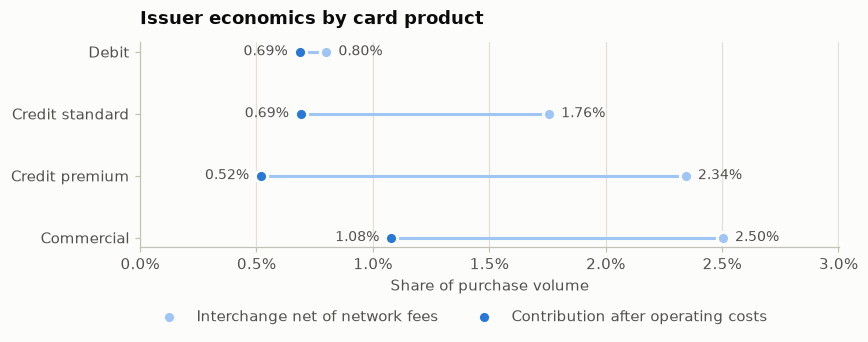

In [7]:
lines = (
    issuer_contribution(pnl)
    .with_columns(
        pl.col("product").cast(pl.Utf8),
        (pl.col("issuer_gross_cop") / pl.col("gdv_cop")).alias("gross"),
        pl.col("issuer_contribution_rate").alias("contribution"),
    )
    .sort(pl.col("product").replace_strict(PRODUCT_ORDER))
)
y = np.arange(lines.height)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hlines(y, lines["contribution"], lines["gross"], color=BLUES[1], linewidth=2)
ax.scatter(
    lines["gross"],
    y,
    s=64,
    color=BLUES[1],
    edgecolors=SURFACE,
    linewidths=2,
    zorder=3,
    label="Interchange net of network fees",
)
ax.scatter(
    lines["contribution"],
    y,
    s=64,
    color=SERIES[0],
    edgecolors=SURFACE,
    linewidths=2,
    zorder=3,
    label="Contribution after operating costs",
)
for yi, (gross, contribution) in enumerate(zip(lines["gross"], lines["contribution"], strict=True)):
    ax.annotate(
        f"{gross:.2%}",
        xy=(gross, yi),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        color=INK_2,
        fontsize=9,
    )
    ax.annotate(
        f"{contribution:.2%}",
        xy=(contribution, yi),
        xytext=(-8, 0),
        textcoords="offset points",
        va="center",
        ha="right",
        color=INK_2,
        fontsize=9,
    )
ax.set_yticks(y, [pretty(p) for p in lines["product"]])
ax.invert_yaxis()
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.set_xlim(min(0.0, lines["contribution"].min() * 1.3), lines["gross"].max() * 1.2)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Share of purchase volume")
ax.set_title("Issuer economics by card product")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.24), ncol=2)
fig.tight_layout()
plt.show()

In [8]:
ISSUER_LINES = {
    "interchange_cop": "interchange",
    "issuer_network_fee_cop": "network fees",
    "rewards_cop": "rewards",
    "funding_cop": "funding",
    "credit_loss_cop": "credit loss",
    "issuer_processing_cop": "processing",
    "fraud_loss_cop": "fraud",
    "issuer_contribution_cop": "contribution",
}
lines.select(
    "product",
    (pl.col("gdv_cop") / gdv).alias("share of GDV"),
    *((pl.col(c) / pl.col("gdv_cop")).alias(name) for c, name in ISSUER_LINES.items()),
).with_columns(cs.float().round(4))

product,share of GDV,interchange,network fees,rewards,funding,credit loss,processing,fraud,contribution
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""debit""",0.5198,0.0086,0.0006,0.0,0.0,0.0,0.001,0.0001,0.0069
"""credit_standard""",0.1845,0.0183,0.0007,0.004,0.002,0.003,0.0015,0.0002,0.0069
"""credit_premium""",0.1847,0.0249,0.0015,0.012,0.0025,0.0015,0.002,0.0002,0.0052
"""commercial""",0.111,0.0261,0.0011,0.008,0.003,0.001,0.002,0.0002,0.0108


Premium cards earn the highest interchange among consumer cards, but rewards take
about half of it and they end with the thinnest contribution; commercial cards keep the
most. Debit keeps most of its smaller interchange because it carries no rewards or credit
costs, so it contributes about as much per peso of volume as standard credit.

### Where fixed fees bite

The network charges the issuer a fixed authorization fee per purchase, while small domestic
tickets in grocery, transport and restaurants pay a reduced interchange rate with no fixed
part. On those tickets the issuer receives less interchange than it pays the network: a fee
structure problem that a small-ticket network fee, or a fixed interchange component, would
fix. It is one of the levers the optimizer will be able to move.

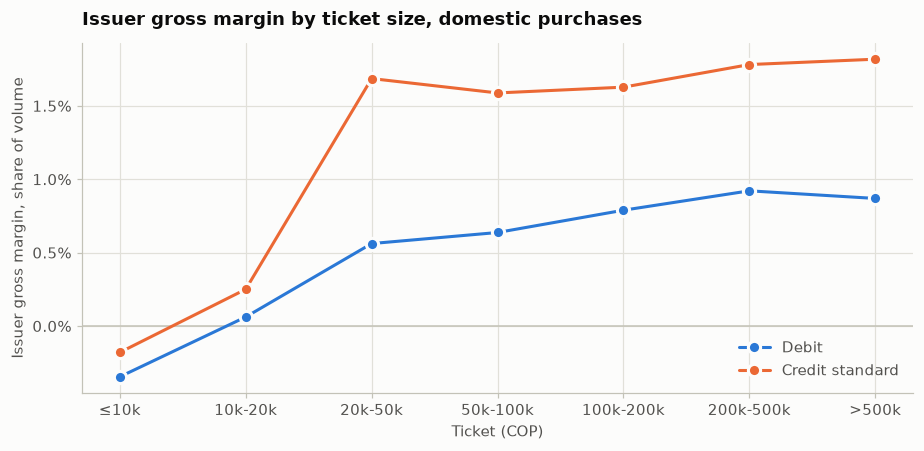

Small-ticket tier: up to 20,000 COP at 0.20% interchange; issuer authorization fee: 40 COP


product,ticket,purchases,issuer gross,acquirer gross
str,str,u32,f64,f64
"""debit""","""≤10k""","369,905",-0.0035,0.0081
"""debit""","""10k-20k""","666,468",0.0006,0.0089
"""debit""","""20k-50k""","1,192,992",0.0056,0.0072
"""debit""","""50k-100k""","844,079",0.0064,0.0074
"""debit""","""100k-200k""","476,682",0.0079,0.0074
"""debit""","""200k-500k""","270,306",0.0092,0.0073
"""debit""",""">500k""","213,037",0.0087,0.0067
"""credit_standard""","""≤10k""","48,944",-0.0018,0.0074
"""credit_standard""","""10k-20k""","118,445",0.0025,0.0075


In [9]:
tier = cfg.interchange_table.small_ticket
breaks = [10_000, 20_000, 50_000, 100_000, 200_000, 500_000]
tickets = ["≤10k", "10k-20k", "20k-50k", "50k-100k", "100k-200k", "200k-500k", ">500k"]
by_ticket = (
    pnl.transactions.filter(~pl.col("cross_border"))
    .with_columns(
        pl.col("amount_cop").cut(breaks, labels=tickets).cast(pl.Utf8).alias("ticket"),
        pl.col("product").cast(pl.Utf8),
    )
    .group_by("product", "ticket")
    .agg(
        pl.len().alias("purchases"),
        (pl.col("issuer_gross_cop").sum() / pl.col("amount_cop").sum()).alias("issuer gross"),
        (pl.col("acquirer_gross_cop").sum() / pl.col("amount_cop").sum()).alias("acquirer gross"),
    )
    .with_columns(
        pl.col("ticket").replace_strict({t: i for i, t in enumerate(tickets)}).alias("bucket")
    )
    .sort(pl.col("product").replace_strict(PRODUCT_ORDER), "bucket")
)
shown = ["debit", "credit_standard"]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axhline(0, color=AXIS, linewidth=1)
for i, product in enumerate(shown):
    line = by_ticket.filter(pl.col("product") == product)
    ax.plot(
        line["bucket"],
        line["issuer gross"],
        color=SERIES[i],
        marker="o",
        markersize=8,
        markeredgecolor=SURFACE,
        markeredgewidth=2,
        label=pretty(product),
    )
ax.set_xticks(range(len(tickets)), tickets)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.set_xlabel("Ticket (COP)")
ax.set_ylabel("Issuer gross margin, share of volume")
ax.set_title("Issuer gross margin by ticket size, domestic purchases")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()
print(
    f"Small-ticket tier: up to {tier.max_amount_cop:,.0f} COP at {tier.rate:.2%} interchange; "
    f"issuer authorization fee: {cfg.economics.network.issuer.authorization_fee_cop:,.0f} COP"
)
by_ticket.filter(pl.col("product").is_in(shown)).select(
    "product", "ticket", "purchases", "issuer gross", "acquirer gross"
).with_columns(cs.float().round(4))

## 3. The network: revenue by driver

Network revenue in bps of purchase volume, split by the fee that produces it: the
assessment on both sides (a share of the amount), the authorization fee (fixed per purchase,
so it weighs more where tickets are small) and the cross-border fees, which apply only when
the merchant is abroad.

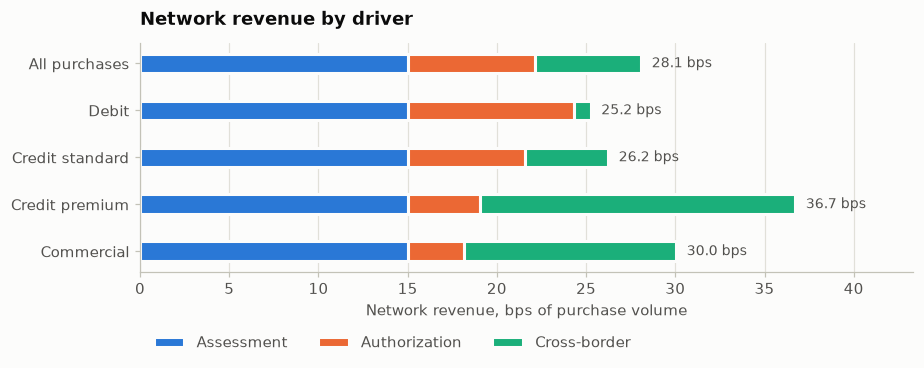

segment,Assessment,Authorization,Cross-border,total bps
str,f64,f64,f64,f64
"""All purchases""",15.0,7.16,5.92,28.08
"""Debit""",15.0,9.3,0.95,25.25
"""Credit standard""",15.0,6.6,4.63,26.23
"""Credit premium""",15.0,4.07,17.64,36.71
"""Commercial""",15.0,3.17,11.87,30.04


In [10]:
DRIVERS = {
    "network_assessment_cop": "Assessment",
    "network_authorization_cop": "Authorization",
    "network_cross_border_cop": "Cross-border",
}
by_product = net_revenue_yield(pnl, by=["product"]).with_columns(pl.col("product").cast(pl.Utf8))
frames = [("All purchases", net_revenue_yield(pnl))] + [
    (pretty(p), by_product.filter(pl.col("product") == p)) for p in PRODUCTS
]
drivers = pl.DataFrame(
    [
        {
            "segment": name,
            **{
                label: frame[column].item() / frame["gdv_cop"].item() * 1e4
                for column, label in DRIVERS.items()
            },
            "total bps": frame["net_revenue_yield_bps"].item(),
        }
        for name, frame in frames
    ]
)
y = np.arange(drivers.height)
left = np.zeros(drivers.height)
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, label in enumerate(DRIVERS.values()):
    ax.barh(
        y,
        drivers[label],
        left=left,
        height=0.42,
        color=SERIES[i],
        edgecolor=SURFACE,
        linewidth=2,
        label=label,
    )
    left += drivers[label].to_numpy()
for yi, total in enumerate(drivers["total bps"]):
    ax.text(total + 0.6, yi, f"{total:.1f} bps", va="center", color=INK_2, fontsize=9)
ax.set_yticks(y, drivers["segment"])
ax.invert_yaxis()
ax.set_xlim(0, drivers["total bps"].max() * 1.18)
ax.set_xlabel("Network revenue, bps of purchase volume")
ax.grid(axis="y", visible=False)
ax.set_title("Network revenue by driver")
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.22))
fig.tight_layout()
plt.show()
drivers.with_columns(cs.float().round(2))

In [11]:
net_revenue_yield(pnl, by=["cross_border"]).select(
    pl.when(pl.col("cross_border"))
    .then(pl.lit("cross-border"))
    .otherwise(pl.lit("domestic"))
    .alias("region"),
    (pl.col("gdv_cop") / gdv).alias("share of GDV"),
    (pl.col("network_revenue_cop") / totals["network_revenue_cop"]).alias(
        "share of network revenue"
    ),
    pl.col("net_revenue_yield_bps").alias("yield bps"),
).with_columns(cs.float().round(3))

region,share of GDV,share of network revenue,yield bps
str,f64,f64,f64
"""domestic""",0.953,0.759,22.371
"""cross-border""",0.047,0.241,142.842


Cross-border purchases are under 5% of the volume but bring more than a fifth of the
network's revenue, which is why premium and commercial cards, the ones that buy abroad,
carry the highest yield. Debit leans more on the fixed authorization fee because its
tickets are smaller.

## 4. Merchants: relative burden

Relative burden is the merchant's effective MDR divided by its sector margin: the share of
its margin that card acceptance takes, and the main predictor of dropping acceptance
(Feature 5). Dot = median merchant of the group, line = 10th to 90th percentile.

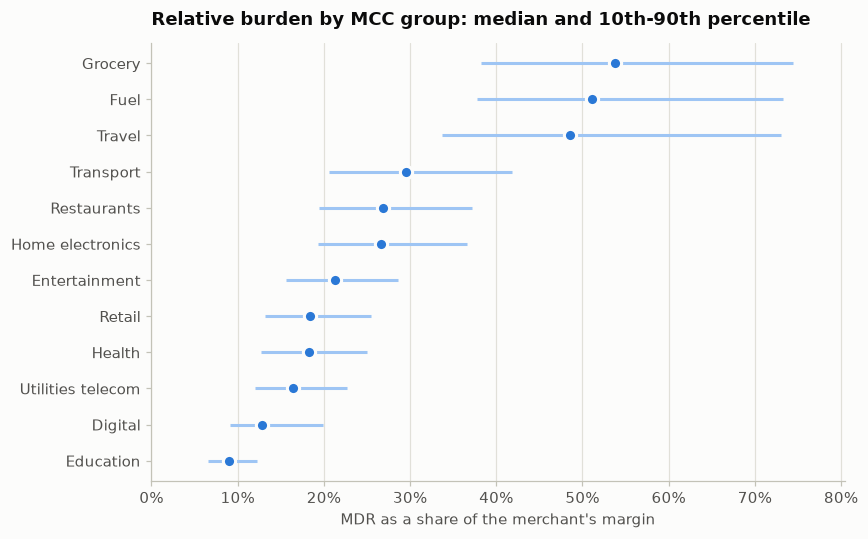

mcc_group,merchants,p10,median,p90,median MDR,median margin
str,u32,f64,f64,f64,f64,f64
"""education""",927,0.066,0.09,0.122,0.014,0.148
"""digital""","1,532",0.091,0.128,0.199,0.024,0.2
"""utilities_telecom""",587,0.12,0.164,0.227,0.016,0.099
"""health""","2,451",0.128,0.183,0.25,0.018,0.098
"""retail""","8,548",0.132,0.183,0.255,0.022,0.12
"""entertainment""","1,500",0.156,0.213,0.286,0.022,0.1
"""home_electronics""","2,088",0.193,0.267,0.366,0.022,0.08
"""restaurants""","2,964",0.195,0.268,0.372,0.022,0.08
"""transport""","1,448",0.206,0.296,0.418,0.02,0.069


In [12]:
burden = relative_burden(pnl, merchants)
by_group = (
    burden.group_by(pl.col("mcc_group").cast(pl.Utf8))
    .agg(
        pl.len().alias("merchants"),
        pl.col("relative_burden").quantile(0.10).alias("p10"),
        pl.col("relative_burden").median().alias("median"),
        pl.col("relative_burden").quantile(0.90).alias("p90"),
        pl.col("effective_mdr_rate").median().alias("median MDR"),
        pl.col("sector_margin").median().alias("median margin"),
    )
    .sort("median")
)
y = np.arange(by_group.height)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(y, by_group["p10"], by_group["p90"], color=BLUES[1], linewidth=2)
ax.scatter(by_group["median"], y, s=64, color=SERIES[0], edgecolors=SURFACE, linewidths=2, zorder=3)
ax.set_yticks(y, [pretty(g) for g in by_group["mcc_group"]])
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, by_group["p90"].max() * 1.08)
ax.grid(axis="y", visible=False)
ax.set_xlabel("MDR as a share of the merchant's margin")
ax.set_title("Relative burden by MCC group: median and 10th-90th percentile")
fig.tight_layout()
plt.show()
by_group.with_columns(cs.float().round(3))

Low-margin sectors carry the heaviest burden even though they pay some of the lowest
rates: grocery and fuel merchants give up about half of their margin to card acceptance,
and travel merchants almost as much. They are the first merchants a price increase would
push out of acceptance (Feature 5).

## 5. Blended or IC++

Each pair of bars prices the same domestic purchases of a merchant tier two ways: at the
blended list rate of their MCC group, and at IC++ (interchange and the acquirer's network
fees at cost, plus the markup). The blended rate carries the acquirer's full margin, while
IC++ passes each merchant's card mix through at cost. Bank acquirers offer IC++ to large
and medium merchants; everyone else pays the list rate.

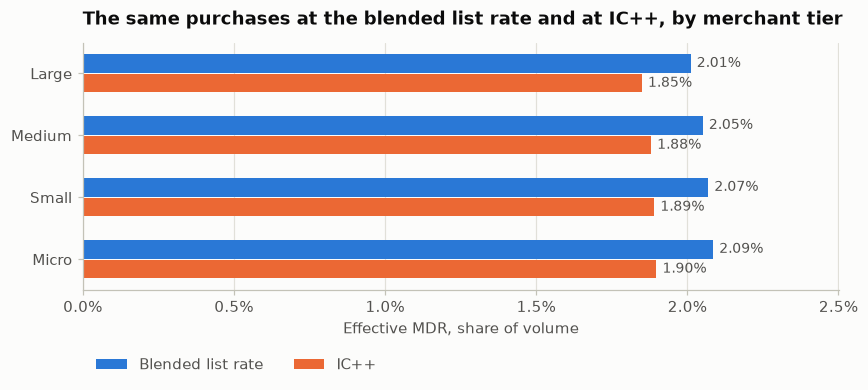

size_tier,merchants,share of domestic GDV,IC++ share of volume,MDR paid,if blended,if IC++
str,u32,f64,f64,f64,f64,f64
"""large""",300,0.1527,0.9474,0.0186,0.0201,0.0185
"""medium""","2,701",0.3245,0.6639,0.0194,0.0205,0.0188
"""small""","9,003",0.3486,0.0,0.0207,0.0207,0.0189
"""micro""","17,917",0.1741,0.0,0.0209,0.0209,0.019


In [13]:
merchant_cost = MerchantCost.from_config(cfg)
domestic = (
    pnl.transactions.filter(~pl.col("cross_border"))
    .select(
        "merchant_id",
        "acquirer_id",
        "mcc_group",
        "cross_border",
        "amount_cop",
        "pricing_model",
        "interchange_cop",
        "acquirer_network_fee_cop",
        "mdr_cop",
    )
    .join(merchants.select("merchant_id", pl.col("size_tier").cast(pl.Utf8)), on="merchant_id")
)


def mdr_if(model):
    # Mismas compras, otro modelo de precio: la fórmula de MDR del P&L, sin duplicarla.
    repriced = domestic.with_columns(pl.lit(model).alias("pricing_model"))
    return repriced.with_columns(merchant_cost.mdr())["mdr_cop"]


comparison = (
    domestic.with_columns(mdr_if("blended").alias("blended_mdr"), mdr_if("icpp").alias("icpp_mdr"))
    .group_by("size_tier")
    .agg(
        pl.col("merchant_id").n_unique().alias("merchants"),
        (pl.col("amount_cop").sum() / domestic["amount_cop"].sum()).alias("share of domestic GDV"),
        (
            pl.col("amount_cop").filter(pl.col("pricing_model") == "icpp").sum()
            / pl.col("amount_cop").sum()
        ).alias("IC++ share of volume"),
        (pl.col("mdr_cop").sum() / pl.col("amount_cop").sum()).alias("MDR paid"),
        (pl.col("blended_mdr").sum() / pl.col("amount_cop").sum()).alias("if blended"),
        (pl.col("icpp_mdr").sum() / pl.col("amount_cop").sum()).alias("if IC++"),
    )
    .sort(pl.col("size_tier").replace_strict({t: i for i, t in enumerate(SIZE_TIERS)}))
)
y = np.arange(comparison.height)
fig, ax = plt.subplots(figsize=(8, 3.8))
for i, (column, label) in enumerate([("if blended", "Blended list rate"), ("if IC++", "IC++")]):
    bars = ax.barh(
        y + (i - 0.5) * 0.32, comparison[column], height=0.3, color=SERIES[i], label=label
    )
    ax.bar_label(
        bars, labels=[f"{v:.2%}" for v in comparison[column]], padding=4, color=INK_2, fontsize=9
    )
ax.set_yticks(y, [pretty(t) for t in comparison["size_tier"]])
ax.invert_yaxis()
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.set_xlim(0, comparison["if blended"].max() * 1.2)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Effective MDR, share of volume")
ax.set_title("The same purchases at the blended list rate and at IC++, by merchant tier")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.22), ncol=2)
fig.tight_layout()
plt.show()
comparison.with_columns(cs.float().round(4))

At these parameters IC++ is cheaper for every tier, by the gap between the acquirer
margin built into the list rate and the negotiated markup. Large and medium merchants,
mostly on IC++, therefore pay less than small and micro merchants, who stay on the list
rate: the blended margin is where aggregators earn.

## 6. Revenue bridge, 2024 to 2025

Network revenue in 2025 against 2024, split into four drivers: total volume, the
cross-border share of it, the product x MCC group x channel mix within each region, and the
network's yield in each segment (rate). The split uses Shapley values over the 16
combinations of old and new drivers, so the effects add up exactly to the change and do not
depend on the order in which they are applied.

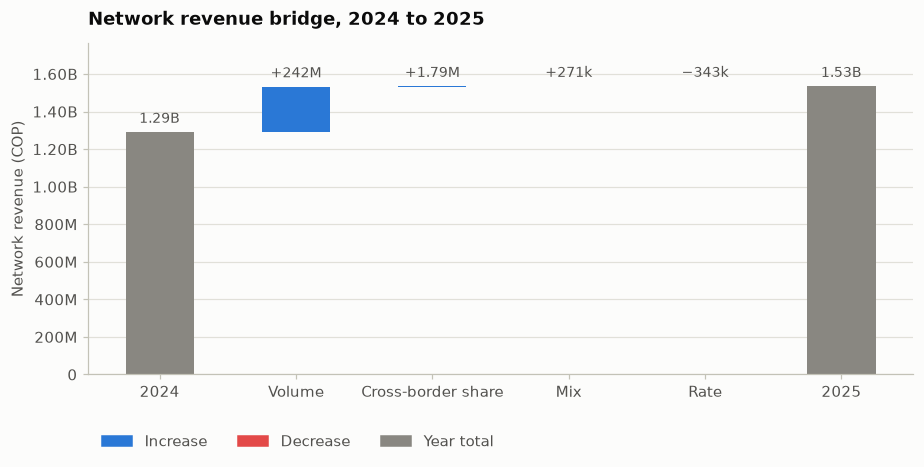

step,value_cop,share of change
str,f64,f64
"""base""","1,290,430,458.2305",null
"""volume""","242,288,396.5271",0.9929
"""cross_border""","1,794,639.7328",0.0074
"""mix""","271,492.3476",0.0011
"""rate""","-342,765.5524",-0.0014
"""new""","1,534,442,221.2855",null


In [14]:
year = pl.col("txn_date").dt.year()
bridge = revenue_bridge(
    pnl.transactions.filter(year == 2024), pnl.transactions.filter(year == 2025)
)
assert abs(sum(bridge.effects.values()) - bridge.change) <= 1e-9 * abs(bridge.change)
steps = ["2024", "Volume", "Cross-border share", "Mix", "Rate", "2025"]
values = [bridge.base_revenue, *bridge.effects.values(), bridge.new_revenue]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
running = bridge.base_revenue
for i, value in enumerate(values):
    if i in (0, len(values) - 1):
        bottom, height, color, text = 0.0, value, MUTED, compact(value)
    else:
        bottom = running if value >= 0 else running + value
        height, color = abs(value), (UP if value >= 0 else DOWN)
        text = ("+" if value >= 0 else "−") + compact(abs(value))
        running += value
    ax.bar(i, height, bottom=bottom, width=0.5, color=color)
    ax.annotate(
        text,
        xy=(i, bottom + height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color=INK_2,
        fontsize=9,
    )
ax.set_xticks(range(len(steps)), steps)
ax.yaxis.set_major_formatter(FuncFormatter(compact))
ax.set_ylim(0, max(values) * 1.15)
ax.set_ylabel("Network revenue (COP)")
ax.grid(axis="x", visible=False)
ax.set_title("Network revenue bridge, 2024 to 2025")
legend = [("Increase", UP), ("Decrease", DOWN), ("Year total", MUTED)]
ax.legend(
    handles=[Patch(color=c, label=n) for n, c in legend],
    loc="upper left",
    bbox_to_anchor=(0, -0.14),
    ncol=3,
)
fig.tight_layout()
plt.show()
bridge.frame().with_columns(
    pl.when(pl.col("step").is_in(["base", "new"]))
    .then(None)
    .otherwise(pl.col("value_cop") / bridge.change)
    .alias("share of change")
).with_columns(cs.float().round(4))

Volume explains almost all of the growth: the generator grows purchases 19% a year
and keeps fees, propensities and the mix constant, so the other three effects are sampling
noise. That is what makes the bridge useful later: in Feature 6 the same decomposition
attributes the revenue change of a pricing scenario to volume, mix and rates.

## Limits

- **Synthetic data.** The economics follow from the parameters in `config/economics.yaml`
  and `config/mcc_groups.yaml`; `docs/assumptions.md` marks which come from literature and
  which are own assumptions. The notebook shows what the framework computes, not the
  Colombian market.
- **Network revenue is gross.** The model has no client incentives and no value-added
  services. For reference, in 2025 Visa and Mastercard earned about 29-31 bps of payments
  volume net of incentives (value-added services included) and about 37-38 bps gross from
  the payment network.
- **Issuer contribution is payments economics only:** no interest income, no losses on
  revolving balances, no fixed costs.
- **The foreign acquirer** is seen only through purchases with Colombian cards.
- **Merchants do not react yet:** acceptance responds to relative burden in Feature 5.

In [15]:
print(f"Notebook runtime: {time.perf_counter() - start:.1f} s")

Notebook runtime: 6.3 s
